In [2]:
from google.colab import drive
drive.mount('/content/drive')

# Create a project folder in your Drive if you haven't yet
import os
project_path = '/content/drive/MyDrive/Statsbomb_Data'
if not os.path.exists(project_path):
    os.makedirs(project_path)

print(f"Drive mounted. Please move your CSV to: {project_path}")

Mounted at /content/drive
Drive mounted. Please move your CSV to: /content/drive/MyDrive/Statsbomb_Data


In [9]:
import shutil
import os

# Once the file is visible in the sidebar, this will move it to Drive
source = '01_raw_modern_master_shots.csv'
destination = '/content/drive/MyDrive/Statsbomb_Data/01_raw_modern_master_shots.csv'

if os.path.exists(source):
    shutil.move(source, destination)
    print("✅ Success! The file is now safely stored in your Google Drive.")
else:
    print("❌ The file isn't in the sidebar yet. Wait for the upload to finish!")

❌ The file isn't in the sidebar yet. Wait for the upload to finish!


In [12]:
import os
# List everything in the current folder
files = os.listdir('.')
print("Files currently in the sidebar:")
for f in files:
    if 'csv' in f:
        print(f"- {f}")

Files currently in the sidebar:


In [13]:
import os
import shutil

# Look for any CSV file in the current directory
sidebar_files = os.listdir('.')
csv_files = [f for f in sidebar_files if f.endswith('.csv')]

if csv_files:
    # We take the first CSV we find
    found_file = csv_files[0]
    destination = '/content/drive/MyDrive/Statsbomb_Data/01_raw_modern_master_shots.csv'

    shutil.move(found_file, destination)
    print(f"✅ Found and moved: {found_file} to Drive!")
else:
    print("❌ No CSV files detected in the sidebar. Please try dragging the file in one more time.")

❌ No CSV files detected in the sidebar. Please try dragging the file in one more time.


In [14]:
from google.colab import files
import shutil
import os

# This will open a file picker
uploaded = files.upload()

for filename in uploaded.keys():
    print(f'User uploaded file "{filename}" with length {len(uploaded[filename])} bytes')

    # Move it to your permanent Drive folder immediately
    destination = '/content/drive/MyDrive/Statsbomb_Data/01_raw_modern_master_shots.csv'
    shutil.move(filename, destination)
    print(f"✅ Success! Moved {filename} to your permanent Drive folder.")

Saving 01_raw_modern_master_shots.csv to 01_raw_modern_master_shots.csv
User uploaded file "01_raw_modern_master_shots.csv" with length 153130450 bytes
✅ Success! Moved 01_raw_modern_master_shots.csv to your permanent Drive folder.


In [15]:
import pandas as pd

# Load the dataset from your permanent Drive path
path = '/content/drive/MyDrive/Statsbomb_Data/01_raw_modern_master_shots.csv'
df = pd.read_csv(path)

# 1. See the size of the data
print(f"Total Rows: {len(df)}")
print(f"Total Columns: {len(df.columns)}")

# 2. See the first 5 rows
print("\n--- First 5 Rows ---")
display(df.head())

# 3. See all column names
print("\n--- All Column Names ---")
print(df.columns.tolist())

# 4. Basic Data Types and Non-Null Counts
print("\n--- Data Summary (Info) ---")
df.info()

Total Rows: 64898
Total Columns: 42

--- First 5 Rows ---


,id,index,period,timestamp,minute,second,type,possession,possession_team,play_pattern,...,competition_name,season_name,shot_deflected,out,shot_open_goal,shot_saved_off_target,shot_saved_to_post,off_camera,shot_redirect,shot_follows_dribble
0,c577e730-b9f5-44f2-9257-9e7730c23d7b,436,1,00:06:48.773,6,48,Shot,13,Werder Bremen,From Free Kick,...,1. Bundesliga,2023/2024,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,bbc2c68d-c096-483d-abf4-32c0175a0f55,480,1,00:07:40.953,7,40,Shot,14,Bayer Leverkusen,Regular Play,...,1. Bundesliga,2023/2024,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,12b5206b-9ed0-4b1e-9ec3-f2028187e09f,597,1,00:11:08.471,11,8,Shot,22,Werder Bremen,From Free Kick,...,1. Bundesliga,2023/2024,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,b2c3d59d-3bef-4f8a-ad86-26b69940c64e,684,1,00:13:16.073,13,16,Shot,26,Bayer Leverkusen,From Corner,...,1. Bundesliga,2023/2024,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,bb53b537-1685-4019-9e8f-98f3805828eb,848,1,00:16:00.956,16,0,Shot,33,Bayer Leverkusen,Regular Play,...,1. Bundesliga,2023/2024,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



--- All Column Names ---
['id', 'index', 'period', 'timestamp', 'minute', 'second', 'type', 'possession', 'possession_team', 'play_pattern', 'team', 'player', 'position', 'location', 'duration', 'related_events', 'match_id', 'shot_statsbomb_xg', 'shot_end_location', 'shot_first_time', 'shot_technique', 'shot_body_part', 'shot_type', 'shot_outcome', 'shot_freeze_frame', 'possession_team_id', 'team_id', 'player_id', 'under_pressure', 'shot_key_pass_id', 'shot_aerial_won', 'shot_one_on_one', 'competition_name', 'season_name', 'shot_deflected', 'out', 'shot_open_goal', 'shot_saved_off_target', 'shot_saved_to_post', 'off_camera', 'shot_redirect', 'shot_follows_dribble']

--- Data Summary (Info) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64898 entries, 0 to 64897
Data columns (total 42 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     64898 non-null  object 
 1   index                  648

In [16]:
import pandas as pd

# 1. Define the 21 columns we are keeping (The "Signal")
columns_to_keep = [
    # Spatial & Physics
    'location', 'shot_body_part', 'shot_technique',

    # Tactical Context (The Boolean/sparse features)
    'play_pattern', 'shot_first_time', 'under_pressure',
    'shot_one_on_one', 'shot_deflected', 'shot_open_goal',
    'shot_redirect', 'shot_follows_dribble', 'shot_aerial_won',

    # Timeline
    'period', 'minute',

    # Labels & Benchmarks
    'shot_outcome', 'shot_statsbomb_xg',

    # Identity (For filtering/verification later)
    'player', 'team', 'competition_name', 'season_name'
]

# 2. Create the slimmed-down dataframe
# We use a list comprehension to ensure we only grab columns that actually exist
existing_cols = [c for c in columns_to_keep if c in df.columns]
df_slim = df[existing_cols].copy()

# 3. Final Verification of the Split
total_cols_before = df.shape[1]
total_cols_after = df_slim.shape[1]
dropped_count = total_cols_before - total_cols_after

print(f"✅ df_slim created successfully!")
print(f"Total rows: {df_slim.shape[0]}")
print(f"Columns Kept: {total_cols_after}")
print(f"Columns Dropped: {dropped_count}")
print("-" * 30)
print("Remaining Columns:", df_slim.columns.tolist())

# Show the first few rows to ensure data integrity
df_slim.head()

✅ df_slim created successfully!
Total rows: 64898
Columns Kept: 20
Columns Dropped: 22
------------------------------
Remaining Columns: ['location', 'shot_body_part', 'shot_technique', 'play_pattern', 'shot_first_time', 'under_pressure', 'shot_one_on_one', 'shot_deflected', 'shot_open_goal', 'shot_redirect', 'shot_follows_dribble', 'shot_aerial_won', 'period', 'minute', 'shot_outcome', 'shot_statsbomb_xg', 'player', 'team', 'competition_name', 'season_name']


,location,shot_body_part,shot_technique,play_pattern,shot_first_time,under_pressure,shot_one_on_one,shot_deflected,shot_open_goal,shot_redirect,shot_follows_dribble,shot_aerial_won,period,minute,shot_outcome,shot_statsbomb_xg,player,team,competition_name,season_name
0,"[100.4, 35.1]",Right Foot,Normal,From Free Kick,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,6,Blocked,0.056644,Leonardo Bittencourt,Werder Bremen,1. Bundesliga,2023/2024
1,"[114.6, 33.5]",Left Foot,Normal,Regular Play,True,True,NaN,NaN,NaN,NaN,NaN,NaN,1,7,Saved,0.143381,Piero Martín Hincapié Reyna,Bayer Leverkusen,1. Bundesliga,2023/2024
2,"[106.2, 55.8]",Left Foot,Normal,From Free Kick,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,11,Blocked,0.038188,Julián Malatini,Werder Bremen,1. Bundesliga,2023/2024
3,"[113.9, 47.4]",Head,Normal,From Corner,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,13,Blocked,0.052781,Jonathan Tah,Bayer Leverkusen,1. Bundesliga,2023/2024
4,"[89.2, 42.5]",Left Foot,Normal,Regular Play,NaN,True,NaN,NaN,NaN,NaN,NaN,NaN,1,16,Blocked,0.021272,Granit Xhaka,Bayer Leverkusen,1. Bundesliga,2023/2024


In [17]:
import ast

# 1. Function to safely parse the location string/list
def extract_coords(loc):
    try:
        # If it's a string like "[120, 40]", convert to list. If already a list, stay as list.
        if isinstance(loc, str):
            loc = ast.literal_eval(loc)
        return pd.Series([loc[0], loc[1]])
    except:
        return pd.Series([None, None])

# 2. Apply the split
df_slim[['x', 'y']] = df_slim['location'].apply(extract_coords)

# 3. Drop the original location column (optional, but keeps it clean)
df_slim = df_slim.drop(columns=['location'])

print("✅ Location split into 'x' and 'y' columns.")
print(df_slim[['x', 'y']].head())

✅ Location split into 'x' and 'y' columns.
       x     y
0  100.4  35.1
1  114.6  33.5
2  106.2  55.8
3  113.9  47.4
4   89.2  42.5


In [18]:
df_slim.head()

,shot_body_part,shot_technique,play_pattern,shot_first_time,under_pressure,shot_one_on_one,shot_deflected,shot_open_goal,shot_redirect,shot_follows_dribble,...,period,minute,shot_outcome,shot_statsbomb_xg,player,team,competition_name,season_name,x,y
0,Right Foot,Normal,From Free Kick,True,NaN,NaN,NaN,NaN,NaN,NaN,...,1,6,Blocked,0.056644,Leonardo Bittencourt,Werder Bremen,1. Bundesliga,2023/2024,100.4,35.1
1,Left Foot,Normal,Regular Play,True,True,NaN,NaN,NaN,NaN,NaN,...,1,7,Saved,0.143381,Piero Martín Hincapié Reyna,Bayer Leverkusen,1. Bundesliga,2023/2024,114.6,33.5
2,Left Foot,Normal,From Free Kick,True,NaN,NaN,NaN,NaN,NaN,NaN,...,1,11,Blocked,0.038188,Julián Malatini,Werder Bremen,1. Bundesliga,2023/2024,106.2,55.8
3,Head,Normal,From Corner,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1,13,Blocked,0.052781,Jonathan Tah,Bayer Leverkusen,1. Bundesliga,2023/2024,113.9,47.4
4,Left Foot,Normal,Regular Play,NaN,True,NaN,NaN,NaN,NaN,NaN,...,1,16,Blocked,0.021272,Granit Xhaka,Bayer Leverkusen,1. Bundesliga,2023/2024,89.2,42.5


In [19]:
# 1. Get a list of all current columns
cols = df_slim.columns.tolist()

# 2. Remove 'x' and 'y' from their current positions
cols.remove('x')
cols.remove('y')

# 3. Create the new order with 'x' and 'y' at the index 0 and 1
new_col_order = ['x', 'y'] + cols

# 4. Apply the new order to the dataframe
df_slim = df_slim[new_col_order]

print("✅ 'x' and 'y' moved to the start of the dataframe.")
print(f"New column order: {df_slim.columns.tolist()[:5]} ...")

# 5. Show the first few rows to confirm the change
df_slim.head()

✅ 'x' and 'y' moved to the start of the dataframe.
New column order: ['x', 'y', 'shot_body_part', 'shot_technique', 'play_pattern'] ...


,x,y,shot_body_part,shot_technique,play_pattern,shot_first_time,under_pressure,shot_one_on_one,shot_deflected,shot_open_goal,...,shot_follows_dribble,shot_aerial_won,period,minute,shot_outcome,shot_statsbomb_xg,player,team,competition_name,season_name
0,100.4,35.1,Right Foot,Normal,From Free Kick,True,NaN,NaN,NaN,NaN,...,NaN,NaN,1,6,Blocked,0.056644,Leonardo Bittencourt,Werder Bremen,1. Bundesliga,2023/2024
1,114.6,33.5,Left Foot,Normal,Regular Play,True,True,NaN,NaN,NaN,...,NaN,NaN,1,7,Saved,0.143381,Piero Martín Hincapié Reyna,Bayer Leverkusen,1. Bundesliga,2023/2024
2,106.2,55.8,Left Foot,Normal,From Free Kick,True,NaN,NaN,NaN,NaN,...,NaN,NaN,1,11,Blocked,0.038188,Julián Malatini,Werder Bremen,1. Bundesliga,2023/2024
3,113.9,47.4,Head,Normal,From Corner,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,1,13,Blocked,0.052781,Jonathan Tah,Bayer Leverkusen,1. Bundesliga,2023/2024
4,89.2,42.5,Left Foot,Normal,Regular Play,NaN,True,NaN,NaN,NaN,...,NaN,NaN,1,16,Blocked,0.021272,Granit Xhaka,Bayer Leverkusen,1. Bundesliga,2023/2024


In [20]:
# 1. Define the columns that represent tactical 'tags'
bool_cols = [
    'shot_first_time', 'under_pressure', 'shot_one_on_one',
    'shot_deflected', 'shot_open_goal', 'shot_redirect',
    'shot_follows_dribble', 'shot_aerial_won'
]

# 2. Fill NaNs with 0 (meaning 'No' or 'False')
df_slim[bool_cols] = df_slim[bool_cols].fillna(0)

# 3. Replace any actual True/False objects with 1/0
df_slim = df_slim.replace({True: 1, False: 0})

print("✅ NaNs filled and Boolean values converted to 1/0.")

/tmp/ipykernel_2687/2875820452.py:12: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_slim = df_slim.replace({True: 1, False: 0})


✅ NaNs filled and Boolean values converted to 1/0.


In [21]:
# 1. Check Data Types
print("--- Final Column Data Types ---")
print(df_slim.dtypes)

--- Final Column Data Types ---
x                       float64
y                       float64
shot_body_part           object
shot_technique           object
play_pattern             object
shot_first_time           int64
under_pressure            int64
shot_one_on_one           int64
shot_deflected            int64
shot_open_goal            int64
shot_redirect             int64
shot_follows_dribble      int64
shot_aerial_won           int64
period                    int64
minute                    int64
shot_outcome             object
shot_statsbomb_xg       float64
player                   object
team                     object
competition_name         object
season_name              object
dtype: object


In [22]:
print("\n--- Missing Values Summary ---")
print(df_slim.isnull().sum())


--- Missing Values Summary ---
x                       0
y                       0
shot_body_part          0
shot_technique          0
play_pattern            0
shot_first_time         0
under_pressure          0
shot_one_on_one         0
shot_deflected          0
shot_open_goal          0
shot_redirect           0
shot_follows_dribble    0
shot_aerial_won         0
period                  0
minute                  0
shot_outcome            0
shot_statsbomb_xg       0
player                  0
team                    0
competition_name        0
season_name             0
dtype: int64


In [23]:
df_slim.head()

,x,y,shot_body_part,shot_technique,play_pattern,shot_first_time,under_pressure,shot_one_on_one,shot_deflected,shot_open_goal,...,shot_follows_dribble,shot_aerial_won,period,minute,shot_outcome,shot_statsbomb_xg,player,team,competition_name,season_name
0,100.4,35.1,Right Foot,Normal,From Free Kick,1,0,0,0,0,...,0,0,1,6,Blocked,0.056644,Leonardo Bittencourt,Werder Bremen,1. Bundesliga,2023/2024
1,114.6,33.5,Left Foot,Normal,Regular Play,1,1,0,0,0,...,0,0,1,7,Saved,0.143381,Piero Martín Hincapié Reyna,Bayer Leverkusen,1. Bundesliga,2023/2024
2,106.2,55.8,Left Foot,Normal,From Free Kick,1,0,0,0,0,...,0,0,1,11,Blocked,0.038188,Julián Malatini,Werder Bremen,1. Bundesliga,2023/2024
3,113.9,47.4,Head,Normal,From Corner,0,0,0,0,0,...,0,0,1,13,Blocked,0.052781,Jonathan Tah,Bayer Leverkusen,1. Bundesliga,2023/2024
4,89.2,42.5,Left Foot,Normal,Regular Play,0,1,0,0,0,...,0,0,1,16,Blocked,0.021272,Granit Xhaka,Bayer Leverkusen,1. Bundesliga,2023/2024


In [24]:
# Check unique values for our categorical columns
categorical_cols = ['shot_body_part', 'shot_technique', 'play_pattern']

for col in categorical_cols:
    print(f"--- Unique values in {col} ---")
    print(df_slim[col].unique())
    print("\n")

--- Unique values in shot_body_part ---
['Right Foot' 'Left Foot' 'Head' 'Other']


--- Unique values in shot_technique ---
['Normal' 'Volley' 'Half Volley' 'Lob' 'Backheel' 'Overhead Kick'
 'Diving Header']


--- Unique values in play_pattern ---
['From Free Kick' 'Regular Play' 'From Corner' 'Other' 'From Keeper'
 'From Throw In' 'From Goal Kick' 'From Counter' 'From Kick Off']




In [25]:
# Check counts for each category to see if any are too rare
for col in ['shot_body_part', 'shot_technique', 'play_pattern']:
    print(f"--- Distribution for {col} ---")
    print(df_slim[col].value_counts())
    print("-" * 30)

--- Distribution for shot_body_part ---
shot_body_part
Right Foot    33248
Left Foot     21140
Head          10323
Other           187
Name: count, dtype: int64
------------------------------
--- Distribution for shot_technique ---
shot_technique
Normal           50069
Half Volley       9021
Volley            4278
Lob                659
Overhead Kick      371
Diving Header      252
Backheel           248
Name: count, dtype: int64
------------------------------
--- Distribution for play_pattern ---
play_pattern
Regular Play      21511
From Free Kick    13603
From Throw In     11218
From Corner       10270
From Counter       2881
From Goal Kick     2515
Other              1087
From Keeper        1079
From Kick Off       734
Name: count, dtype: int64
------------------------------


In [26]:
# 1. Select the columns to encode
cols_to_encode = ['shot_body_part', 'shot_technique', 'play_pattern']

# 2. Perform One-Hot Encoding
# 'drop_first=True' is a statistical trick to avoid the "Dummy Variable Trap"
# (if it's not Left Foot or Head, it MUST be Right Foot, so we don't need all 3 columns).
# However, for XGBoost, keeping all columns (drop_first=False) is often clearer for feature importance.
df_encoded = pd.get_dummies(df_slim, columns=cols_to_encode, prefix=['body', 'tech', 'pattern'])

# 3. Convert the new True/False columns to 1/0 integers
# This ensures consistency with your other boolean columns
new_bool_cols = df_encoded.select_dtypes(include=['bool']).columns
df_encoded[new_bool_cols] = df_encoded[new_bool_cols].astype(int)

print(f"✅ Encoding Complete! New shape: {df_encoded.shape}")
print(f"Added {df_encoded.shape[1] - df_slim.shape[1]} new feature columns.")

✅ Encoding Complete! New shape: (64898, 38)
Added 17 new feature columns.


In [27]:
df_slim.head()

,x,y,shot_body_part,shot_technique,play_pattern,shot_first_time,under_pressure,shot_one_on_one,shot_deflected,shot_open_goal,...,shot_follows_dribble,shot_aerial_won,period,minute,shot_outcome,shot_statsbomb_xg,player,team,competition_name,season_name
0,100.4,35.1,Right Foot,Normal,From Free Kick,1,0,0,0,0,...,0,0,1,6,Blocked,0.056644,Leonardo Bittencourt,Werder Bremen,1. Bundesliga,2023/2024
1,114.6,33.5,Left Foot,Normal,Regular Play,1,1,0,0,0,...,0,0,1,7,Saved,0.143381,Piero Martín Hincapié Reyna,Bayer Leverkusen,1. Bundesliga,2023/2024
2,106.2,55.8,Left Foot,Normal,From Free Kick,1,0,0,0,0,...,0,0,1,11,Blocked,0.038188,Julián Malatini,Werder Bremen,1. Bundesliga,2023/2024
3,113.9,47.4,Head,Normal,From Corner,0,0,0,0,0,...,0,0,1,13,Blocked,0.052781,Jonathan Tah,Bayer Leverkusen,1. Bundesliga,2023/2024
4,89.2,42.5,Left Foot,Normal,Regular Play,0,1,0,0,0,...,0,0,1,16,Blocked,0.021272,Granit Xhaka,Bayer Leverkusen,1. Bundesliga,2023/2024


In [28]:
# 1. Create the binary target 'is_goal'
# If the outcome is 'Goal', it becomes 1. Everything else (Saved, Blocked, Missed) becomes 0.
df_encoded['is_goal'] = (df_encoded['shot_outcome'] == 'Goal').astype(int)

# 2. Check the conversion rate (Average xG of the whole dataset)
conversion_rate = df_encoded['is_goal'].mean()
print(f"✅ Target variable 'is_goal' created.")
print(f"Total Goals: {df_encoded['is_goal'].sum()}")
print(f"Overall Conversion Rate: {conversion_rate:.2%}")

# 3. Drop the original 'shot_outcome' column as it's now redundant
if 'shot_outcome' in df_encoded.columns:
    df_encoded = df_encoded.drop(columns=['shot_outcome'])
    print("🗑️ Original 'shot_outcome' column removed.")

# 4. Quick look at the balance
print("\n--- Value Counts for is_goal ---")
print(df_encoded['is_goal'].value_counts())

✅ Target variable 'is_goal' created.
Total Goals: 7144
Overall Conversion Rate: 11.01%
🗑️ Original 'shot_outcome' column removed.

--- Value Counts for is_goal ---
is_goal
0    57754
1     7144
Name: count, dtype: int64


In [30]:
df_encoded.shape

(64898, 38)

In [31]:
df_encoded.head()

,x,y,shot_first_time,under_pressure,shot_one_on_one,shot_deflected,shot_open_goal,shot_redirect,shot_follows_dribble,shot_aerial_won,...,pattern_From Corner,pattern_From Counter,pattern_From Free Kick,pattern_From Goal Kick,pattern_From Keeper,pattern_From Kick Off,pattern_From Throw In,pattern_Other,pattern_Regular Play,is_goal
0,100.4,35.1,1,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
1,114.6,33.5,1,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
2,106.2,55.8,1,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
3,113.9,47.4,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
4,89.2,42.5,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0


In [32]:
# 1. Get current column list
cols = df_encoded.columns.tolist()

# 2. Remove 'is_goal' from its current position
cols.remove('is_goal')

# 3. Re-insert 'is_goal' at index 2 (which is the 3rd position)
cols.insert(2, 'is_goal')

# 4. Apply the new order
df_encoded = df_encoded[cols]

print("✅ 'is_goal' is now in the 3rd position.")
print(f"Current Header: {df_encoded.columns.tolist()[:5]}")

✅ 'is_goal' is now in the 3rd position.
Current Header: ['x', 'y', 'is_goal', 'shot_first_time', 'under_pressure']


In [33]:
df_encoded.head()

,x,y,is_goal,shot_first_time,under_pressure,shot_one_on_one,shot_deflected,shot_open_goal,shot_redirect,shot_follows_dribble,...,tech_Volley,pattern_From Corner,pattern_From Counter,pattern_From Free Kick,pattern_From Goal Kick,pattern_From Keeper,pattern_From Kick Off,pattern_From Throw In,pattern_Other,pattern_Regular Play
0,100.4,35.1,0,1,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
1,114.6,33.5,0,1,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
2,106.2,55.8,0,1,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
3,113.9,47.4,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
4,89.2,42.5,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


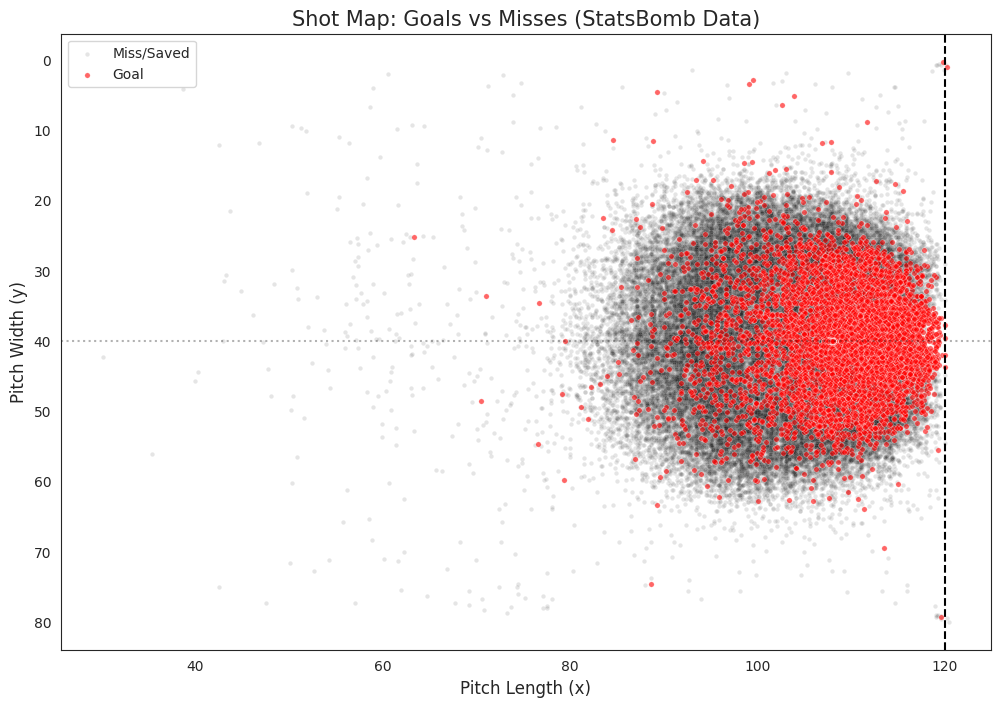

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Set the style
plt.figure(figsize=(12, 8))
sns.set_style("white")

# 2. Plot Non-Goals (0) in grey with high transparency
sns.scatterplot(data=df_encoded[df_encoded['is_goal'] == 0],
                x='x', y='y', color='black', alpha=0.1, s=10, label='Miss/Saved')

# 3. Plot Goals (1) in bright red/orange to make them pop
sns.scatterplot(data=df_encoded[df_encoded['is_goal'] == 1],
                x='x', y='y', color='red', alpha=0.6, s=15, label='Goal')

# 4. Add Pitch Markings (Optional but helpful)
plt.axvline(x=120, color='black', linestyle='--') # Goal line
plt.axhline(y=40, color='black', linestyle=':', alpha=0.3) # Center line of pitch

# 5. Formatting
plt.title('Shot Map: Goals vs Misses (StatsBomb Data)', fontsize=15)
plt.xlabel('Pitch Length (x)', fontsize=12)
plt.ylabel('Pitch Width (y)', fontsize=12)
plt.legend()
plt.gca().invert_yaxis() # Traditional football viz often inverts Y
plt.show()

--- Spatial Statistics: Goals (1) vs. Misses (0) ---


x                           y                  
               mean       std median       mean        std median
is_goal                                                          
0        102.942283  8.743562  104.0  39.708593  10.205235   39.8
1        108.857237  6.091301  109.3  39.833385   6.915162   40.0

/tmp/ipykernel_2687/318606432.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_encoded, x='is_goal', y='x', palette='Reds')


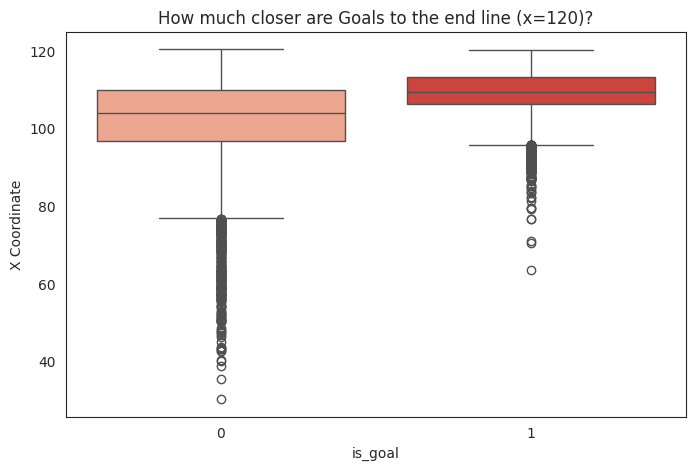

In [36]:
# 1. Compare the centers of gravity for Goals vs. Misses
stats = df_encoded.groupby('is_goal')[['x', 'y']].agg(['mean', 'std', 'median'])
print("--- Spatial Statistics: Goals (1) vs. Misses (0) ---")
display(stats)

# 2. Boxplot to see the spread of X (Closeness to goal)
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.boxplot(data=df_encoded, x='is_goal', y='x', palette='Reds')
plt.title('How much closer are Goals to the end line (x=120)?')
plt.ylabel('X Coordinate')
plt.show()

In [37]:
# 3. Group by Body Part (using the encoded columns)
body_parts = [col for col in df_encoded.columns if 'body_' in col]
print("--- Conversion Rate by Body Part ---")

for part in body_parts:
    subset = df_encoded[df_encoded[part] == 1]
    conv_rate = subset['is_goal'].mean() * 100
    print(f"{part.replace('body_', '')}: {conv_rate:.2f}% (Total shots: {len(subset)})")

--- Conversion Rate by Body Part ---
Head: 10.53% (Total shots: 10323)
Left Foot: 10.68% (Total shots: 21140)
Other: 26.20% (Total shots: 187)
Right Foot: 11.28% (Total shots: 33248)


In [38]:
# 1. Full descriptive statistics for all numeric columns
# We'll transpose it (.T) so it's easier to read on your screen
eda_summary = df_encoded.describe().T

# 2. Add 'Median' and 'Mode' manually since describe() misses them
eda_summary['median'] = df_encoded.median(numeric_only=True)
eda_summary['mode'] = df_encoded.mode(numeric_only=True).iloc[0]

print("--- FULL DATASET DESCRIPTIVE STATISTICS ---")
display(eda_summary.round(3))

# 3. Check for Outliers in X (Shot Distance)
print("\n--- SPATIAL OUTLIER CHECK ---")
print(f"Deepest Shot (Min X): {df_encoded['x'].min()} yards")
print(f"Closest Shot (Max X): {df_encoded['x'].max()} yards")

--- FULL DATASET DESCRIPTIVE STATISTICS ---


,count,mean,std,min,25%,50%,75%,max,median,mode
x,64898.0,103.593,8.692,30.2,97.300,105.000,110.500,120.400,105.000,108.000
y,64898.0,39.722,9.897,0.3,32.400,39.900,47.000,80.000,39.900,40.000
is_goal,64898.0,0.110,0.313,0.0,0.000,0.000,0.000,1.000,0.000,0.000
shot_first_time,64898.0,0.310,0.462,0.0,0.000,0.000,1.000,1.000,0.000,0.000
under_pressure,64898.0,0.248,0.432,0.0,0.000,0.000,0.000,1.000,0.000,0.000
shot_one_on_one,64898.0,0.053,0.225,0.0,0.000,0.000,0.000,1.000,0.000,0.000
shot_deflected,64898.0,0.014,0.118,0.0,0.000,0.000,0.000,1.000,0.000,0.000
shot_open_goal,64898.0,0.011,0.102,0.0,0.000,0.000,0.000,1.000,0.000,0.000
shot_redirect,64898.0,0.002,0.047,0.0,0.000,0.000,0.000,1.000,0.000,0.000
shot_follows_dribble,64898.0,0.001,0.028,0.0,0.000,0.000,0.000,1.000,0.000,0.000



--- SPATIAL OUTLIER CHECK ---
Deepest Shot (Min X): 30.2 yards
Closest Shot (Max X): 120.4 yards


In [39]:
# Save as CSV (standard)
df_encoded.to_csv('shots_cleaned_encoded.csv', index=False)

# OR Save as Parquet (Recommended for Data Science - smaller and faster)
# df_encoded.to_parquet('shots_cleaned_encoded.parquet')

print("✅ Dataframe saved! You can now start a fresh notebook for Feature Engineering.")

✅ Dataframe saved! You can now start a fresh notebook for Feature Engineering.
